# Solution Notebook: Cybersecurity Clustering and Dimensionality Reduction

This notebook provides a full worked solution for the cybersecurity dataset.

It covers:
- data loading and inspection
- preprocessing and feature scaling
- K-means clustering
- DBSCAN clustering
- agglomerative clustering
- PCA for dimensionality reduction
- t-SNE for non-linear visualization
- optional UMAP visualization
- interpretation of clusters in a cybersecurity context

> Note: `hidden_cluster` is used only for evaluation at the end. It is excluded from the unsupervised training pipeline.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors

plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

import warnings
warnings.filterwarnings('ignore')


In [2]:
# Load the dataset
file_path = 'cybersecurity_unsupervised_dataset_12000.csv'
df = pd.read_csv(file_path)

print('Shape:', df.shape)
df.head()


Shape: (12000, 27)


,duration_sec,packets,bytes_in,bytes_out,bytes_total,failed_logins,distinct_dst_ports,distinct_dst_ips,connections_per_min,dns_queries,http_requests,tls_ratio,avg_packet_size,packet_size_var,inbound_ratio,night_activity_ratio,cpu_usage_pct,memory_usage_pct,payload_entropy,external_ip_ratio,geo_diversity_count,syn_error_ratio,session_reuse_ratio,abnormal_port_score,beacon_interval_std,out_in_ratio,hidden_cluster
0,5.471,64,11183,1833,12800,7,2,3,16.724,3.000,40.000,0.045,371.260,17.220,0.489,0.000,52.510,61.800,6.800,0.642,6,0.068,0.046,0.096,94.030,0.164,web_attack
1,23.256,78,3476,6087,9749,8,8,14,17.550,6.000,8.000,0.548,574.120,155.780,0.666,0.467,59.310,67.170,4.649,0.750,3,0.011,0.228,0.396,53.580,1.751,malware_lateral
2,2.987,1646,10778,3214,14117,3,17,23,37.375,2.000,14.000,0.242,154.230,45.560,0.745,0.672,51.260,35.950,2.636,0.908,12,0.227,0.428,0.699,66.530,0.298,ddos_scan
3,7.430,35,4242,3325,7342,15,1,6,10.302,1.000,2.000,0.383,390.770,58.940,0.410,0.290,57.180,52.640,3.441,0.915,8,0.042,0.586,0.103,84.310,0.784,bruteforce_auth
4,54.599,224,1392,8991,10334,0,1,5,5.732,3.000,4.000,0.693,932.790,302.620,0.614,0.057,21.200,51.220,5.808,0.146,3,0.030,0.414,0.047,86.390,6.458,benign_workstation


## 1. Inspect the dataset


In [4]:
print(df.info())
print('Missing values per column:')
print(df.isna().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   duration_sec          12000 non-null  float64
 1   packets               12000 non-null  int64  
 2   bytes_in              12000 non-null  int64  
 3   bytes_out             12000 non-null  int64  
 4   bytes_total           12000 non-null  int64  
 5   failed_logins         12000 non-null  int64  
 6   distinct_dst_ports    12000 non-null  int64  
 7   distinct_dst_ips      12000 non-null  int64  
 8   connections_per_min   12000 non-null  float64
 9   dns_queries           11880 non-null  float64
 10  http_requests         11880 non-null  float64
 11  tls_ratio             12000 non-null  float64
 12  avg_packet_size       12000 non-null  float64
 13  packet_size_var       12000 non-null  float64
 14  inbound_ratio         12000 non-null  float64
 15  night_activity_rati

In [5]:
# Separate the hidden label from the unsupervised features
hidden_label = df['hidden_cluster'].copy()
X = df.drop(columns=['hidden_cluster']).copy()

print('Feature matrix shape:', X.shape)
print('Number of hidden categories:', hidden_label.nunique())
hidden_label.value_counts()


Feature matrix shape: (12000, 26)
Number of hidden categories: 6


,count
hidden_cluster,
benign_workstation,3998
ddos_scan,1877
web_attack,1714
malware_lateral,1658
bruteforce_auth,1577
data_exfil,1176


In [6]:
# Summary statistics
X.describe().T


,count,mean,std,min,25%,50%,75%,max
duration_sec,"12,000.000",30.157,36.905,0.599,9.683,19.290,36.650,672.552
packets,"12,000.000",177.260,282.816,3.000,48.750,87.000,166.000,"4,242.000"
bytes_in,"12,000.000","10,983.459","13,895.857",171.000,"3,262.250","6,823.500","13,645.500","527,283.000"
bytes_out,"12,000.000","8,295.732","13,660.251",137.000,"1,825.750","4,071.000","8,927.750","288,478.000"
bytes_total,"12,000.000","19,280.926","18,340.229",100.000,"8,165.500","14,676.500","24,487.250","529,333.000"
failed_logins,"12,000.000",4.260,6.012,0.000,0.000,2.000,5.000,34.000
distinct_dst_ports,"12,000.000",5.146,6.506,1.000,1.000,3.000,5.000,44.000
distinct_dst_ips,"12,000.000",9.545,8.563,1.000,4.000,6.000,13.000,52.000
connections_per_min,"12,000.000",17.490,26.613,0.915,3.606,7.250,16.897,317.216
dns_queries,"11,880.000",2.924,2.352,0.000,1.000,2.000,4.000,15.000


## 2. Quick exploratory visualization
We use a few feature pairs to see whether behavioral groups may exist.


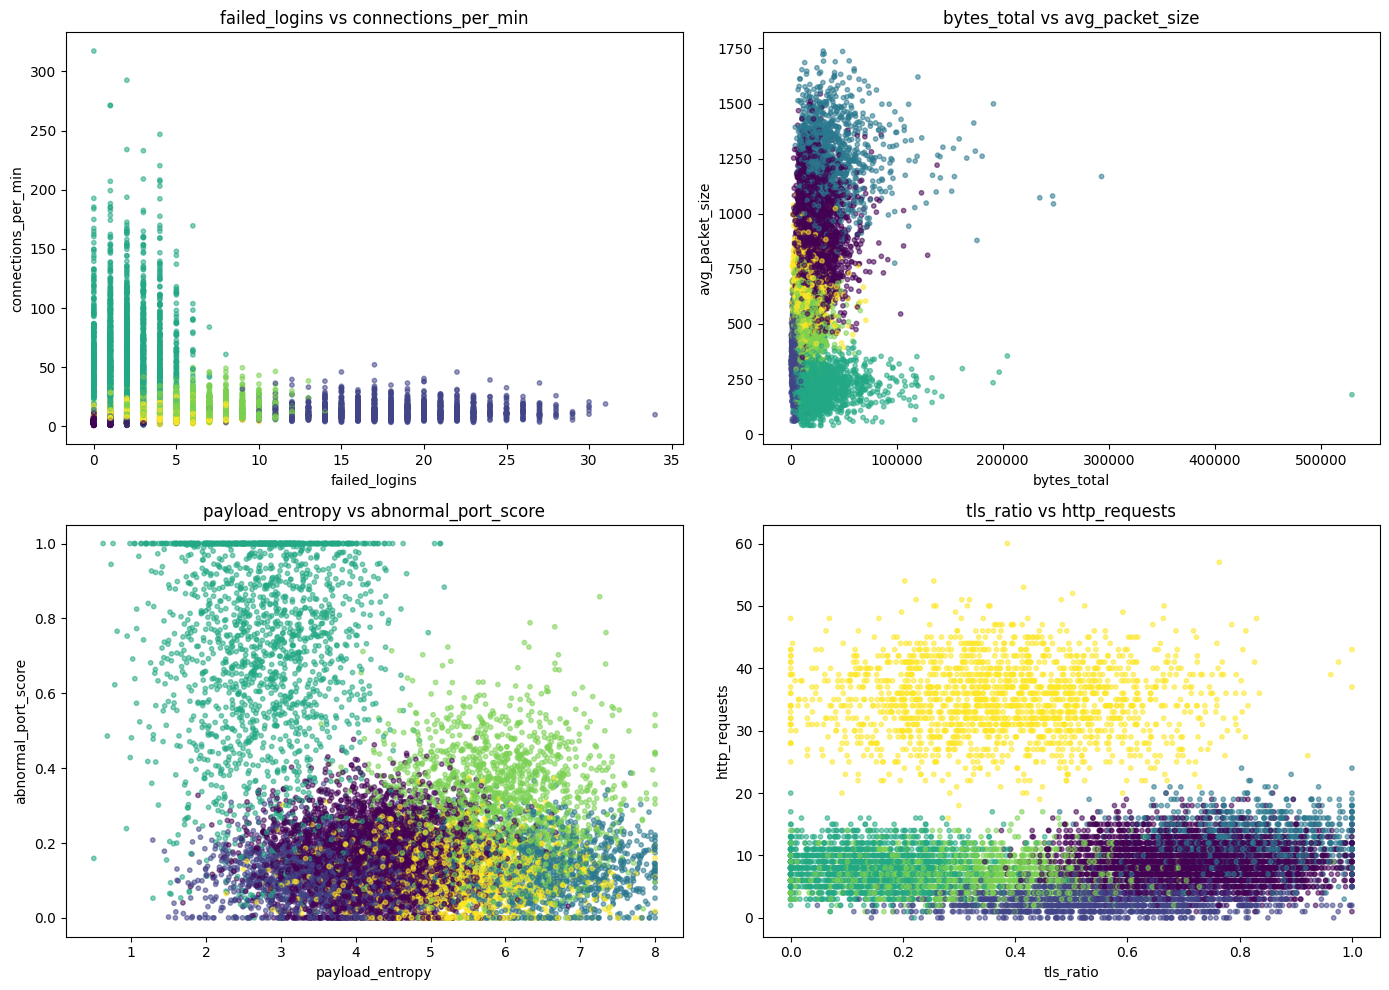

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_pairs = [
    ('failed_logins', 'connections_per_min'),
    ('bytes_total', 'avg_packet_size'),
    ('payload_entropy', 'abnormal_port_score'),
    ('tls_ratio', 'http_requests')
]

for ax, (xcol, ycol) in zip(axes.ravel(), plot_pairs):
    ax.scatter(df[xcol], df[ycol], c=pd.Categorical(hidden_label).codes, s=10, alpha=0.55)
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.set_title(f'{xcol} vs {ycol}')

plt.tight_layout()
plt.show()


## 3. Preprocess the data
Because the features are on very different scales, standardization is important before clustering and PCA.


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Scaled array shape:', X_scaled.shape)
print('Mean of first feature after scaling:', X_scaled[:, 0].mean().round(4))
print('Std of first feature after scaling:', X_scaled[:, 0].std().round(4))


Scaled array shape: (12000, 26)
Mean of first feature after scaling: -0.0
Std of first feature after scaling: 1.0


## 4. Choosing a value of k for K-means
We use both the elbow method and the silhouette score.


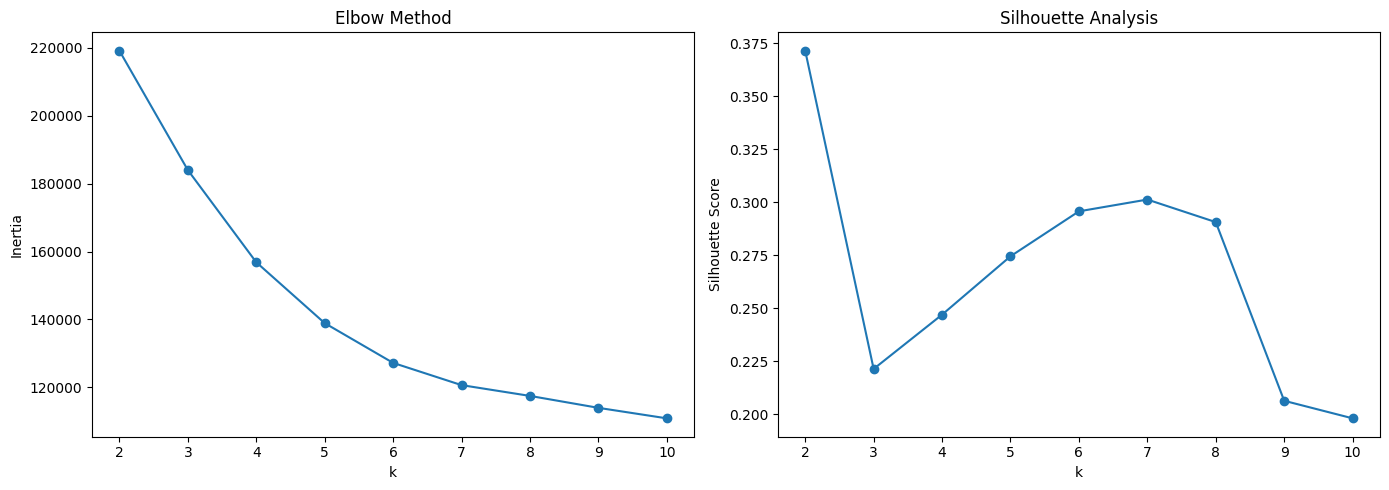

Best k by silhouette score: 2


In [11]:
inertias = []
sil_scores = []
k_values = range(2, 11)

# --- Start of proposed fix for NaN values ---
# The error occurs because X_scaled contains NaN values,
# which KMeans cannot handle. These NaNs originate from
# missing values in the original DataFrame 'X' that were
# propagated during scaling. To fix this, we'll drop rows with
# NaN values from X and then re-scale it. Ideally, this step
# would be performed earlier in the preprocessing section.
# For now, we're handling it here to make this cell runnable.
X_cleaned = X.dropna()

# Re-initialize scaler and re-scale the cleaned data
# Note: This creates a new scaler, ensuring fresh fit on cleaned data
scaler = StandardScaler()
X_scaled_cleaned = scaler.fit_transform(X_cleaned)
# --- End of proposed fix ---


for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    # Use the cleaned and re-scaled data
    labels = km.fit_predict(X_scaled_cleaned)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled_cleaned, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_values), inertias, marker='o')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(list(k_values), sil_scores, marker='o')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')

plt.tight_layout()
plt.show()

best_k = list(k_values)[int(np.argmax(sil_scores))]
print('Best k by silhouette score:', best_k)

## 5. K-means clustering


In [13]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled_cleaned)

print('K-means silhouette score:', round(silhouette_score(X_scaled_cleaned, kmeans_labels), 4))
print(pd.Series(kmeans_labels).value_counts().sort_index())

K-means silhouette score: 0.3714
0    9628
1    1781
Name: count, dtype: int64


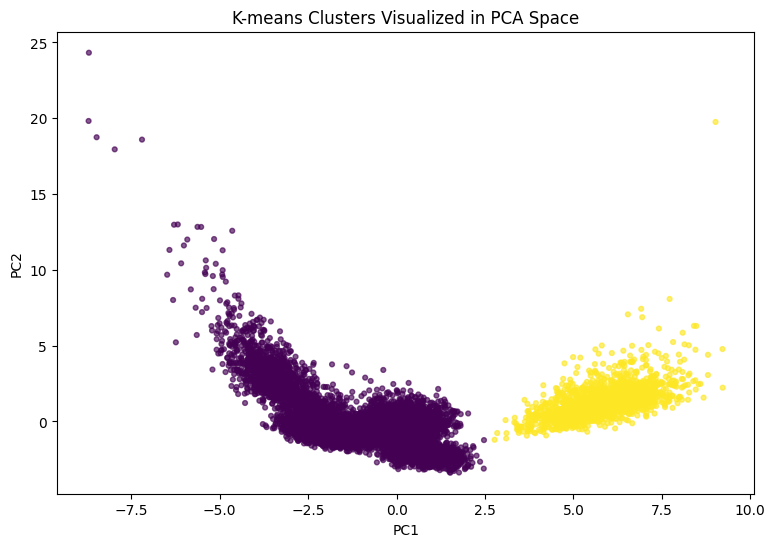

Explained variance ratio: [0.32796407 0.1195163 ]
Total explained variance (2 PCs): 0.4475


In [15]:
# PCA to 2D for visualization
pca_2 = PCA(n_components=2, random_state=42)
X_pca_2 = pca_2.fit_transform(X_scaled_cleaned)

plt.figure(figsize=(9, 6))
plt.scatter(X_pca_2[:, 0], X_pca_2[:, 1], c=kmeans_labels, s=12, alpha=0.65)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-means Clusters Visualized in PCA Space')
plt.show()

print('Explained variance ratio:', pca_2.explained_variance_ratio_)
print('Total explained variance (2 PCs):', pca_2.explained_variance_ratio_.sum().round(4))

In [17]:
# Cluster profiles in original feature space
kmeans_profile = X_cleaned.copy()
kmeans_profile['cluster'] = kmeans_labels
cluster_summary = kmeans_profile.groupby('cluster').mean().round(2)
cluster_summary

,duration_sec,packets,bytes_in,bytes_out,bytes_total,failed_logins,distinct_dst_ports,distinct_dst_ips,connections_per_min,dns_queries,http_requests,tls_ratio,avg_packet_size,packet_size_var,inbound_ratio,night_activity_ratio,cpu_usage_pct,memory_usage_pct,payload_entropy,external_ip_ratio,geo_diversity_count,syn_error_ratio,session_reuse_ratio,abnormal_port_score,beacon_interval_std,out_in_ratio
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,
0,34.110,94.020,"8,435.140","9,451.520","17,888.970",4.650,2.840,6.970,8.230,3.280,12.510,0.580,753.020,266.400,0.440,0.400,40.990,51.930,4.890,0.470,2.770,0.030,0.320,0.160,74.780,3.220
1,9.210,623.310,"24,849.410","2,076.400","26,929.460",2.030,17.610,23.400,67.690,0.990,7.980,0.150,221.750,92.870,0.840,0.440,63.810,47.210,2.810,0.880,8.540,0.220,0.480,0.720,90.480,0.160


### Interpreting K-means clusters
Large values in `failed_logins`, `connections_per_min`, `syn_error_ratio`, `abnormal_port_score`, or `payload_entropy` can indicate suspicious groups such as brute-force activity, scanning, malware-like behavior, or exfiltration-style traffic.


## 6. DBSCAN clustering
DBSCAN can identify dense groups and mark unusual points as noise.


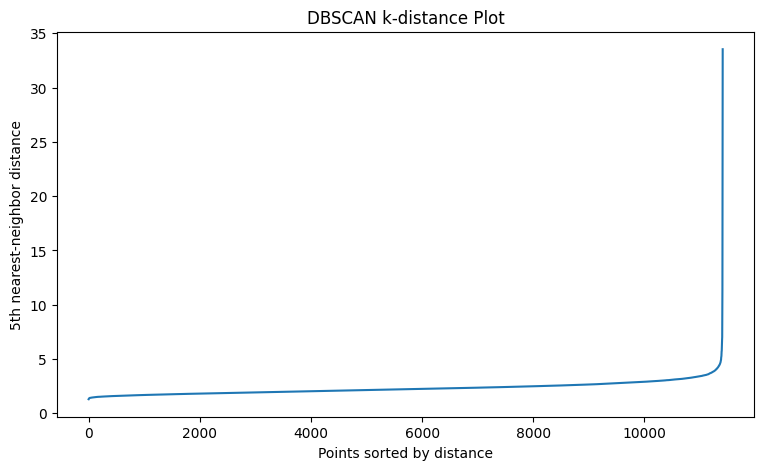

In [19]:
# k-distance style helper plot for choosing eps
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled_cleaned)
distances, indices = neighbors_fit.kneighbors(X_scaled_cleaned)

# distance to the 5th nearest neighbor
kdist = np.sort(distances[:, 4])

plt.figure(figsize=(9, 5))
plt.plot(kdist)
plt.xlabel('Points sorted by distance')
plt.ylabel('5th nearest-neighbor distance')
plt.title('DBSCAN k-distance Plot')
plt.show()

In [21]:
# A reasonable eps for this synthetic data
# You can fine-tune this value after inspecting the k-distance plot.
dbscan = DBSCAN(eps=2.6, min_samples=10)
db_labels = dbscan.fit_predict(X_scaled_cleaned)

unique_db = np.unique(db_labels)
print('DBSCAN labels:', unique_db)
print('Noise points:', np.sum(db_labels == -1))

non_noise_mask = db_labels != -1
if len(np.unique(db_labels[non_noise_mask])) > 1:
    print('DBSCAN silhouette (excluding noise):', round(silhouette_score(X_scaled_cleaned[non_noise_mask], db_labels[non_noise_mask]), 4))
else:
    print('Silhouette score not meaningful because DBSCAN found fewer than 2 non-noise clusters.')

pd.Series(db_labels).value_counts().sort_index()

DBSCAN labels: [-1  0  1]
Noise points: 2048
DBSCAN silhouette (excluding noise): 0.3602


,count
-1,2048
0,8952
1,409


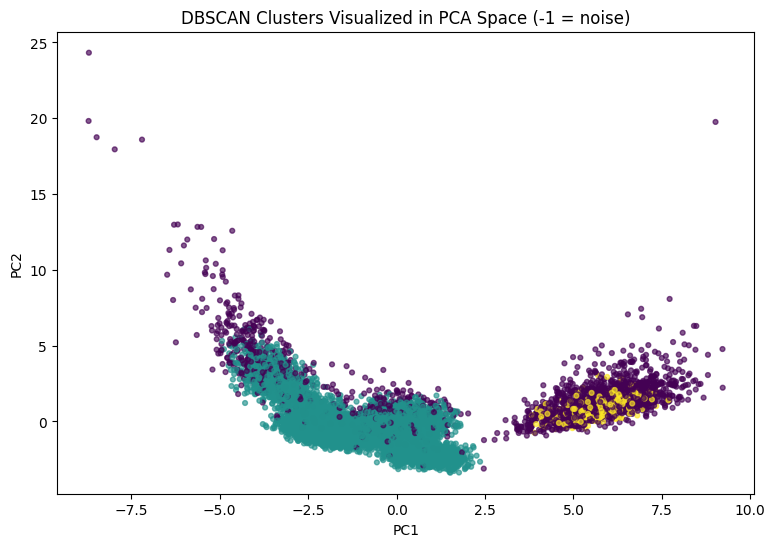

In [22]:
plt.figure(figsize=(9, 6))
plt.scatter(X_pca_2[:, 0], X_pca_2[:, 1], c=db_labels, s=12, alpha=0.65)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('DBSCAN Clusters Visualized in PCA Space (-1 = noise)')
plt.show()


## 7. Agglomerative (hierarchical) clustering
For large datasets, hierarchical clustering can be expensive. We run it directly here because 12,000 rows is still manageable with a simple linkage, but in many practical scenarios you may use a subset.


In [24]:
agg = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
agg_labels = agg.fit_predict(X_scaled_cleaned)

print('Agglomerative silhouette score:', round(silhouette_score(X_scaled_cleaned, agg_labels), 4))
pd.Series(agg_labels).value_counts().sort_index()

Agglomerative silhouette score: 0.3713


,count
0,9627
1,1782


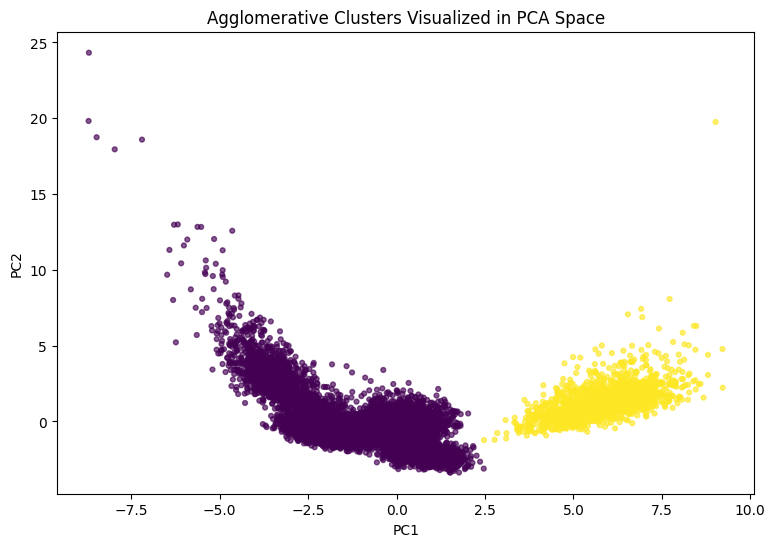

In [25]:
plt.figure(figsize=(9, 6))
plt.scatter(X_pca_2[:, 0], X_pca_2[:, 1], c=agg_labels, s=12, alpha=0.65)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Agglomerative Clusters Visualized in PCA Space')
plt.show()


## 8. Principal Component Analysis (PCA)
PCA reduces dimensionality while preserving as much variance as possible.


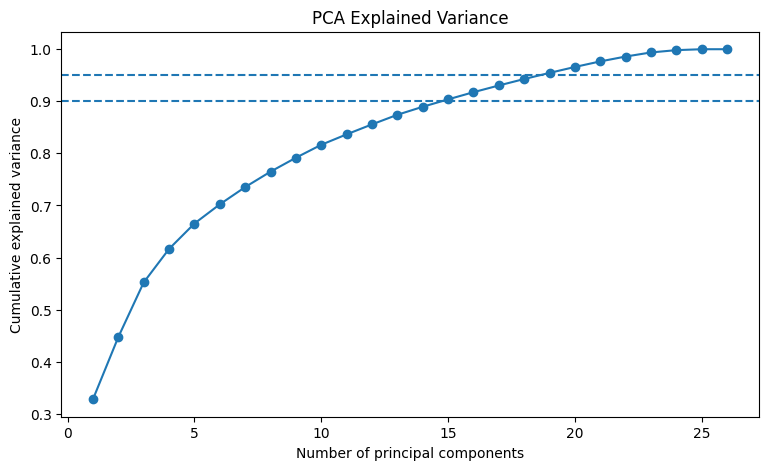

Components for 90% variance: 15
Components for 95% variance: 19


In [27]:
pca_full = PCA().fit(X_scaled_cleaned)
explained = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(explained)+1), explained, marker='o')
plt.xlabel('Number of principal components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA Explained Variance')
plt.axhline(0.90, linestyle='--')
plt.axhline(0.95, linestyle='--')
plt.show()

n90 = np.argmax(explained >= 0.90) + 1
n95 = np.argmax(explained >= 0.95) + 1
print('Components for 90% variance:', n90)
print('Components for 95% variance:', n95)

In [28]:
# Loadings of the first two principal components
loadings = pd.DataFrame(
    pca_2.components_.T,
    index=X.columns,
    columns=['PC1_loading', 'PC2_loading']
).sort_values('PC1_loading', key=np.abs, ascending=False)

loadings.head(10)


,PC1_loading,PC2_loading
syn_error_ratio,0.287,0.145
avg_packet_size,-0.285,0.164
connections_per_min,0.273,0.133
distinct_dst_ips,0.267,0.101
distinct_dst_ports,0.265,0.201
tls_ratio,-0.264,-0.010
abnormal_port_score,0.262,0.197
geo_diversity_count,0.253,0.061
packet_size_var,-0.245,0.159
inbound_ratio,0.224,-0.008


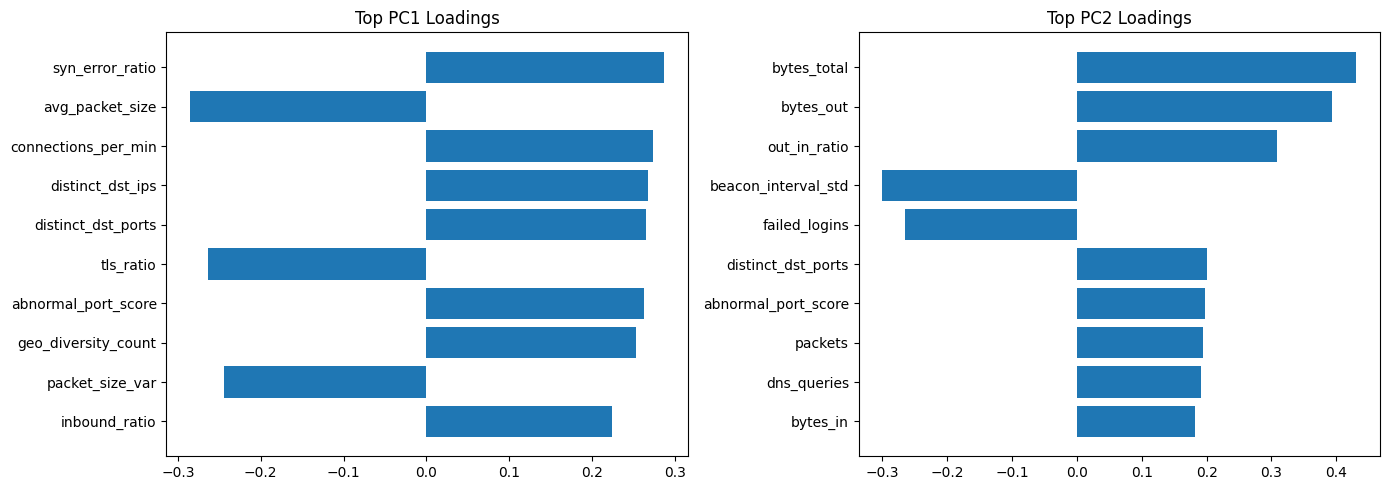

In [29]:
# Top features by absolute loading for PC1 and PC2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pc1_top = loadings['PC1_loading'].abs().sort_values(ascending=False).head(10).index
pc2_top = loadings['PC2_loading'].abs().sort_values(ascending=False).head(10).index

axes[0].barh(pc1_top[::-1], loadings.loc[pc1_top[::-1], 'PC1_loading'])
axes[0].set_title('Top PC1 Loadings')

axes[1].barh(pc2_top[::-1], loadings.loc[pc2_top[::-1], 'PC2_loading'])
axes[1].set_title('Top PC2 Loadings')

plt.tight_layout()
plt.show()


## 9. t-SNE visualization
Unlike PCA, t-SNE focuses on preserving local neighborhood structure and is often good for visualizing non-linear cluster structure.


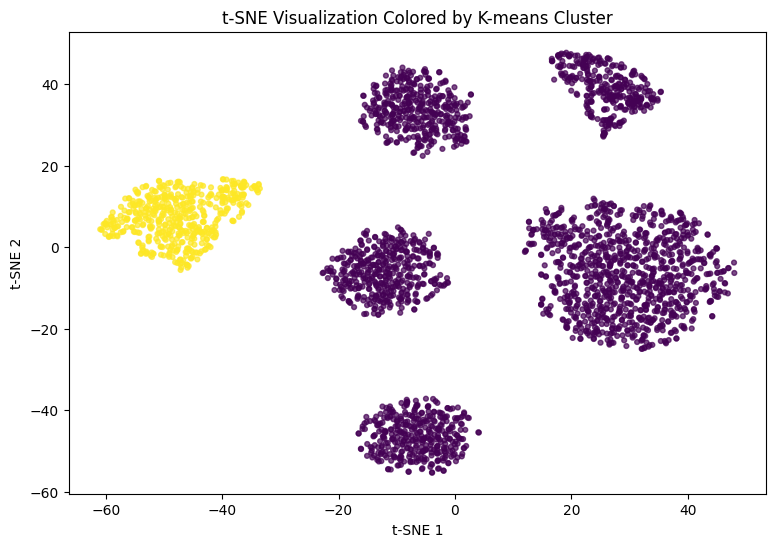

In [31]:
# Use a subset for faster t-SNE plotting if needed
sample_size = 3000

# Generate sample indices from the cleaned data's positional range
current_data_length = len(X_scaled_cleaned)
positional_sample_idx = np.random.RandomState(42).choice(current_data_length, size=sample_size, replace=False)

# Apply sampled indices to the cleaned scaled data and kmeans labels
X_sample = X_scaled_cleaned[positional_sample_idx]
kmeans_sample = kmeans_labels[positional_sample_idx]

# To get the corresponding hidden labels, use the original DataFrame indices from X_cleaned
# This ensures correct mapping back to the 'hidden_label' Series
sampled_original_df_indices = X_cleaned.iloc[positional_sample_idx].index
hidden_sample = hidden_label.loc[sampled_original_df_indices]

tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', random_state=42)
X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(9, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=kmeans_sample, s=12, alpha=0.7)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE Visualization Colored by K-means Cluster')
plt.show()

## 10. Optional UMAP visualization
If `umap-learn` is installed, this section creates another low-dimensional view.


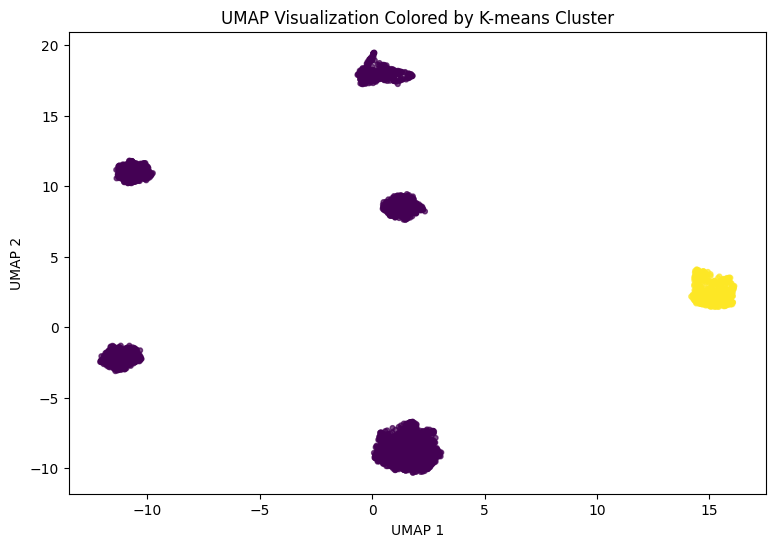

In [32]:
try:
    import umap
    reducer = umap.UMAP(n_components=2, n_neighbors=20, min_dist=0.15, random_state=42)
    X_umap = reducer.fit_transform(X_sample)

    plt.figure(figsize=(9, 6))
    plt.scatter(X_umap[:, 0], X_umap[:, 1], c=kmeans_sample, s=12, alpha=0.7)
    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.title('UMAP Visualization Colored by K-means Cluster')
    plt.show()
except Exception as e:
    print('UMAP section skipped:', e)


## 11. Instructor-side comparison with the hidden synthetic labels
These metrics are **not** normally available in a true unsupervised setting, but they help evaluate how well the clustering recovered the synthetic structure.


In [34]:
label_codes_cleaned = pd.Categorical(hidden_label.loc[X_cleaned.index]).codes
print('Adjusted Rand Index (K-means vs hidden cluster):', round(adjusted_rand_score(label_codes_cleaned, kmeans_labels), 4))
print('Adjusted Rand Index (Agglomerative vs hidden cluster):', round(adjusted_rand_score(label_codes_cleaned, agg_labels), 4))

# DBSCAN ARI can still be computed, including noise label -1
print('Adjusted Rand Index (DBSCAN vs hidden cluster):', round(adjusted_rand_score(label_codes_cleaned, db_labels), 4))

Adjusted Rand Index (K-means vs hidden cluster): 0.1662
Adjusted Rand Index (Agglomerative vs hidden cluster): 0.1664
Adjusted Rand Index (DBSCAN vs hidden cluster): 0.1659


In [38]:
# Confusion-style cross-tab for interpretation
# Filter hidden_label to match the rows present in X_cleaned
filtered_hidden_label = hidden_label.loc[X_cleaned.index]
pd.crosstab(filtered_hidden_label, kmeans_labels, normalize='index').round(2)

col_0,0,1
hidden_cluster,,
benign_workstation,1.000,0.000
bruteforce_auth,1.000,0.000
data_exfil,1.000,0.000
ddos_scan,0.000,1.000
malware_lateral,1.000,0.000
web_attack,1.000,0.000


## 12. Short discussion / answer guide

### What you should conclude
1. **Scaling matters** because the features have very different magnitudes.
2. **K-means** works reasonably well when the clusters are compact in standardized feature space.
3. **DBSCAN** is useful for discovering dense groups and flagging outliers/noise, which is important in cybersecurity.
4. **PCA** provides a linear projection and helps explain variance structure.
5. **t-SNE/UMAP** often produce more visually separated groups for exploration, but they are mainly visualization tools.
6. The cluster profiles can be interpreted as behavioral patterns such as brute-force login attempts, malware-like lateral movement, benign workstation activity, scanning bursts, or high-volume service traffic.


In [40]:
# Save an enriched result table if needed
result_df = X_cleaned.copy()
result_df['hidden_cluster'] = filtered_hidden_label # Add the hidden cluster for comparison
result_df['kmeans_cluster'] = kmeans_labels
result_df['dbscan_cluster'] = db_labels
result_df['agg_cluster'] = agg_labels

result_df.head()

,duration_sec,packets,bytes_in,bytes_out,bytes_total,failed_logins,distinct_dst_ports,distinct_dst_ips,connections_per_min,dns_queries,http_requests,tls_ratio,avg_packet_size,packet_size_var,inbound_ratio,night_activity_ratio,cpu_usage_pct,memory_usage_pct,payload_entropy,external_ip_ratio,geo_diversity_count,syn_error_ratio,session_reuse_ratio,abnormal_port_score,beacon_interval_std,out_in_ratio,hidden_cluster,kmeans_cluster,dbscan_cluster,agg_cluster
0,5.471,64,11183,1833,12800,7,2,3,16.724,3.000,40.000,0.045,371.260,17.220,0.489,0.000,52.510,61.800,6.800,0.642,6,0.068,0.046,0.096,94.030,0.164,web_attack,0,0,0
1,23.256,78,3476,6087,9749,8,8,14,17.550,6.000,8.000,0.548,574.120,155.780,0.666,0.467,59.310,67.170,4.649,0.750,3,0.011,0.228,0.396,53.580,1.751,malware_lateral,0,0,0
2,2.987,1646,10778,3214,14117,3,17,23,37.375,2.000,14.000,0.242,154.230,45.560,0.745,0.672,51.260,35.950,2.636,0.908,12,0.227,0.428,0.699,66.530,0.298,ddos_scan,1,-1,1
3,7.430,35,4242,3325,7342,15,1,6,10.302,1.000,2.000,0.383,390.770,58.940,0.410,0.290,57.180,52.640,3.441,0.915,8,0.042,0.586,0.103,84.310,0.784,bruteforce_auth,0,0,0
4,54.599,224,1392,8991,10334,0,1,5,5.732,3.000,4.000,0.693,932.790,302.620,0.614,0.057,21.200,51.220,5.808,0.146,3,0.030,0.414,0.047,86.390,6.458,benign_workstation,0,0,0
